# Model predykcyjny oparty na regresji liniowej

Celem analizy jest stworzenie modelu umożliwiającego predykcje ceny samochodu w zależności od jego specyfikacji. Lista potemcjalnych regresorów:
* Marka -> bazując na wiedzy rynku samochodowego niektóre marki do co zasady są droższe od innych np. BMW jest droższe od Renault
* Przebieg -> bazując na intuicji, im niższy przebieg, tym droższy samochód powinien być
* Moc silnika -> droższe samochody powinny mieć mocniejszy silnik
* Rocznik -> poza outlierami im starsze auto tym tańsze powinno być

## Przygotowanie danych

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
sns.set_theme()

In [55]:
data = pd.read_csv('cars_data.csv')
data

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
0,Alfa Romeo,Alfa Romeo 147,3000,PLN,Benzyna,159000,2008,Manualna,2.00,0
1,Volvo,Volvo XC 60,129999,PLN,Benzyna,127000,2018,Automatyczna,2.40,0
2,Ford,Ford B-MAX,22900,PLN,Benzyna,161000,2016,Manualna,1.60,0
3,Jaguar,Jaguar I-Pace EV400 AWD SE,69900,PLN,Elektryczny,135125,2019,Automatyczna,2.00,0
4,Cupra,Cupra Formentor VZ 2.0 TSI 4Drive DSG,119999,PLN,Benzyna,81800,2020,Automatyczna,2.00,1
...,...,...,...,...,...,...,...,...,...,...
11993,SsangYong/KGM,SsangYong/KGM Tivoli,35550,PLN,Benzyna,76000,2015,Manualna,2.00,0
11994,Mercedes-Benz,Mercedes-Benz GLE,280000,PLN,Benzyna,61000,2022,Automatyczna,3.00,0
11995,Land Rover,Land Rover Range Rover,79900,PLN,Diesel,290000,2014,Automatyczna,3.00,0
11996,Volkswagen,Volkswagen T-Roc 1.5 TSI R-Line DSG,109900,PLN,Benzyna,14200,2024,Automatyczna,1.50,1


In [56]:
pd.set_option('display.float_format', '{:.2f}'.format)
data.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
count,11998,11998,11998.00,11998,11998,11998.00,11998.00,11998,11998.00,11998.00
unique,99,6619,NaN,1,8,NaN,NaN,2,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Automatyczna,NaN,NaN
freq,920,80,NaN,11998,6462,NaN,NaN,6035,NaN,NaN
mean,NaN,NaN,77316.92,NaN,NaN,142182.88,2016.26,NaN,1.79,0.43
std,NaN,NaN,100117.19,NaN,NaN,100359.24,7.03,NaN,0.59,0.49
min,NaN,NaN,1350.00,NaN,NaN,0.00,1951.00,NaN,1.00,0.00
25%,NaN,NaN,22900.00,NaN,NaN,66600.00,2012.00,NaN,1.50,0.00
50%,NaN,NaN,47000.00,NaN,NaN,139850.00,2017.00,NaN,1.60,0.00
75%,NaN,NaN,95000.00,NaN,NaN,202185.00,2022.00,NaN,2.00,1.00


## PDF dla regresorów

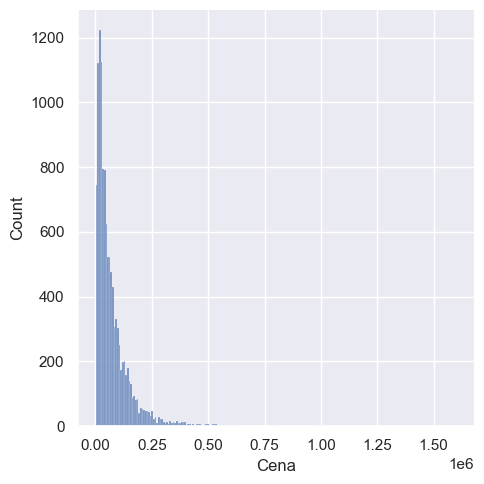

In [57]:
sns.displot(data['Cena'])

## Outliery

In [74]:
q_cena = data['Cena'].quantile(0.99)
data = data[data['Cena'] < q_cena]
data.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
count,11878,11878,11878.00,11878,11878,11878.00,11878.00,11878,11878.00,11878.00
unique,95,6555,NaN,1,8,NaN,NaN,2,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Manualna,NaN,NaN
freq,894,80,NaN,11878,6388,NaN,NaN,5962,NaN,NaN
mean,NaN,NaN,70798.58,NaN,NaN,143476.11,2016.19,NaN,1.78,0.43
std,NaN,NaN,72354.24,NaN,NaN,99993.80,7.02,NaN,0.57,0.50
min,NaN,NaN,1350.00,NaN,NaN,0.00,1951.00,NaN,1.00,0.00
25%,NaN,NaN,22500.00,NaN,NaN,69000.00,2012.00,NaN,1.50,0.00
50%,NaN,NaN,46000.00,NaN,NaN,140121.50,2017.00,NaN,1.60,0.00
75%,NaN,NaN,93458.25,NaN,NaN,203000.00,2022.00,NaN,2.00,1.00


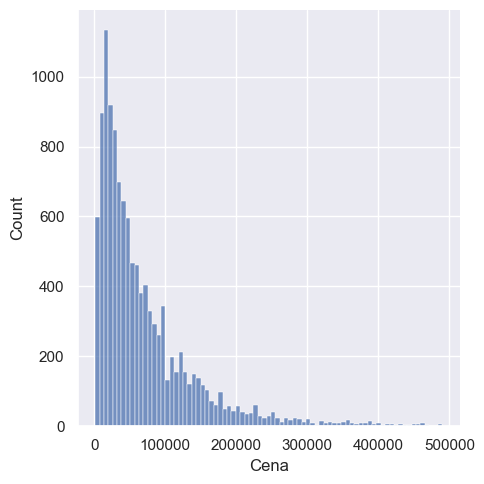

In [75]:
sns.displot(data['Cena'])

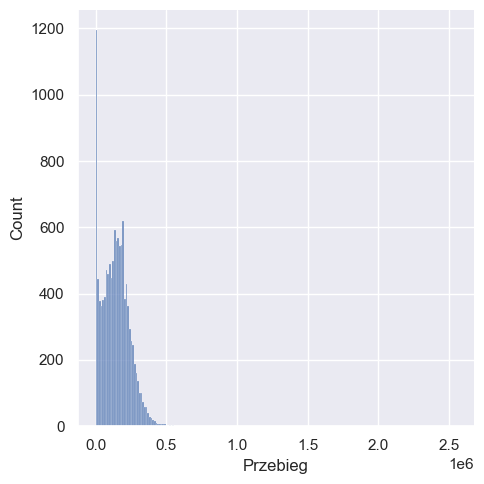

In [60]:
sns.displot(data['Przebieg'])

In [76]:
q_przebieg = data['Przebieg'].quantile(0.99)
data = data[data['Przebieg'] < q_przebieg]

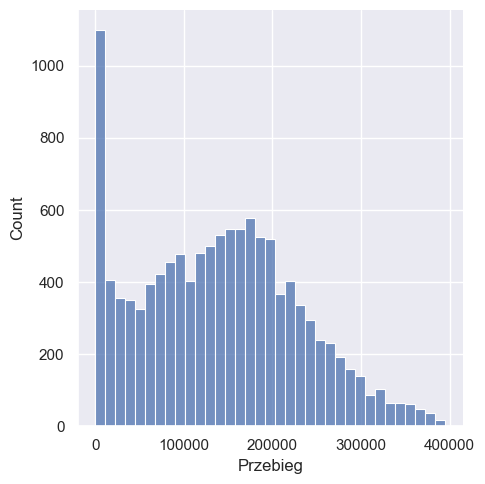

In [77]:
sns.displot(data['Przebieg'])

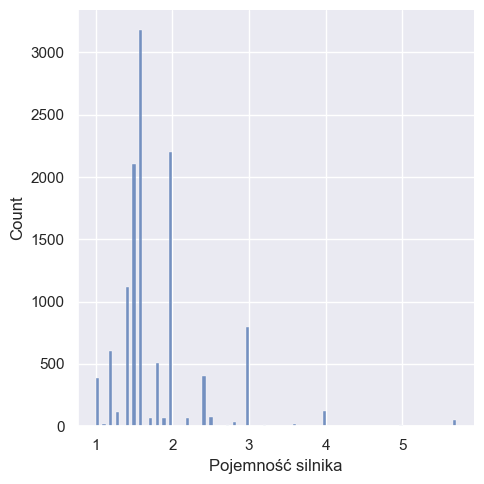

In [63]:
sns.displot(data["Pojemność silnika"])

In [78]:
q_pojemnosc = data['Pojemność silnika'].quantile(0.99)
data= data[data['Pojemność silnika'] < q_pojemnosc]

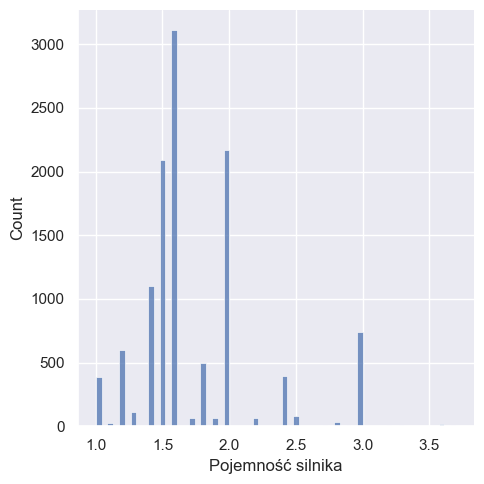

In [79]:
sns.displot(data['Pojemność silnika'])

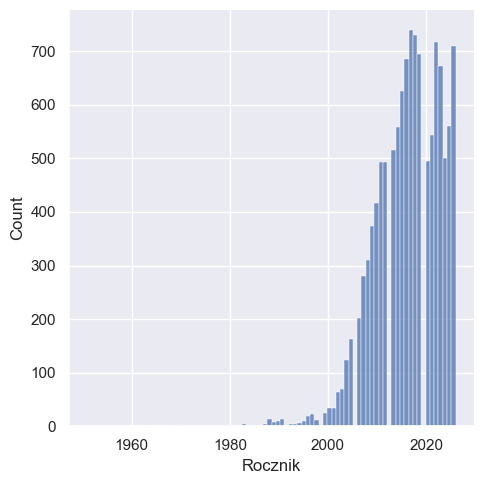

In [70]:
sns.displot(data['Rocznik'])

In [80]:
q_rocznik = data['Rocznik'].quantile(0.01)
data = data[data['Rocznik'] > q_rocznik]

In [81]:
data_cleaned = data.reset_index(drop=True)

In [82]:
data_cleaned.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana
count,11477,11477,11477.00,11477,11477,11477.00,11477.00,11477,11477.00,11477.00
unique,87,6350,NaN,1,8,NaN,NaN,2,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Manualna,NaN,NaN
freq,876,74,NaN,11477,6153,NaN,NaN,5787,NaN,NaN
mean,NaN,NaN,70001.14,NaN,NaN,140290.81,2016.59,NaN,1.74,0.44
std,NaN,NaN,70592.87,NaN,NaN,90275.01,6.15,NaN,0.46,0.50
min,NaN,NaN,1350.00,NaN,NaN,0.00,1997.00,NaN,1.00,0.00
25%,NaN,NaN,22900.00,NaN,NaN,69000.00,2012.00,NaN,1.50,0.00
50%,NaN,NaN,46499.00,NaN,NaN,140000.00,2017.00,NaN,1.60,0.00
75%,NaN,NaN,92250.00,NaN,NaN,201000.00,2022.00,NaN,2.00,1.00


## Założenia OLS

### Linearność

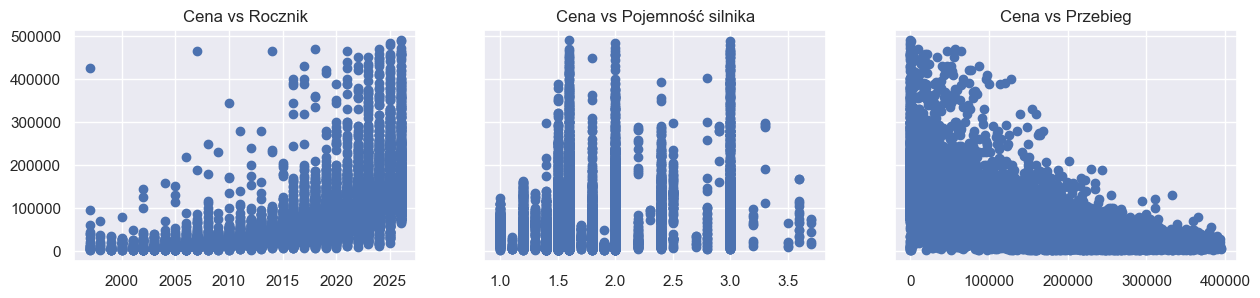

In [83]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15, 3))
ax1.scatter(data_cleaned['Rocznik'], data_cleaned['Cena'])
ax1.set_title('Cena vs Rocznik')
ax2.scatter(data_cleaned['Pojemność silnika'], data_cleaned['Cena'])
ax2.set_title('Cena vs Pojemność silnika')
ax3.scatter(data_cleaned['Przebieg'], data_cleaned['Cena'])
ax3.set_title('Cena vs Przebieg')

plt.show()

W powyższych danych można dostrzec wzorce, jednak zdecydowanie nie są one liniowe, co za tym idzie dane wymagają przekształcenia przy użyciu transformacji logarytmicznej.

In [84]:
log_cena = np.log(data_cleaned['Cena'])
data_cleaned['log_Cena'] = log_cena
data_cleaned.describe(include='all')

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów,Pojemność silnika,Pojemność_znana,log_Cena
count,11477,11477,11477.00,11477,11477,11477.00,11477.00,11477,11477.00,11477.00,11477.00
unique,87,6350,NaN,1,8,NaN,NaN,2,NaN,NaN,NaN
top,BMW,BMW Seria 3,NaN,PLN,Benzyna,NaN,NaN,Manualna,NaN,NaN,NaN
freq,876,74,NaN,11477,6153,NaN,NaN,5787,NaN,NaN,NaN
mean,NaN,NaN,70001.14,NaN,NaN,140290.81,2016.59,NaN,1.74,0.44,10.70
std,NaN,NaN,70592.87,NaN,NaN,90275.01,6.15,NaN,0.46,0.50,1.01
min,NaN,NaN,1350.00,NaN,NaN,0.00,1997.00,NaN,1.00,0.00,7.21
25%,NaN,NaN,22900.00,NaN,NaN,69000.00,2012.00,NaN,1.50,0.00,10.04
50%,NaN,NaN,46499.00,NaN,NaN,140000.00,2017.00,NaN,1.60,0.00,10.75
75%,NaN,NaN,92250.00,NaN,NaN,201000.00,2022.00,NaN,2.00,1.00,11.43


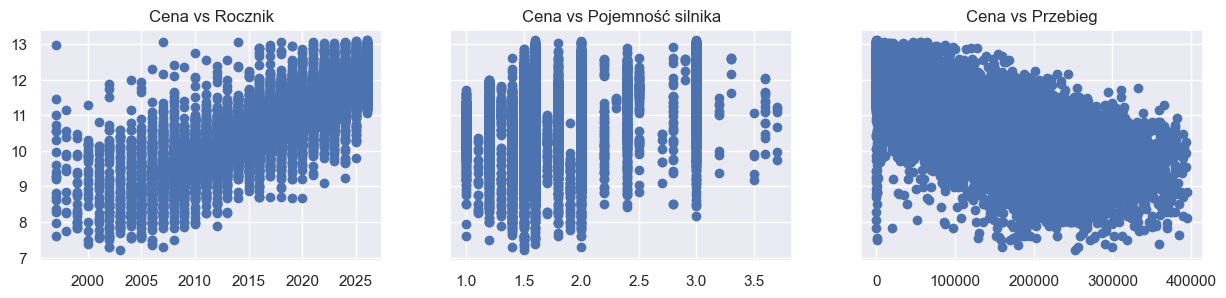

In [85]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15, 3))
ax1.scatter(data_cleaned['Rocznik'], data_cleaned['log_Cena'])
ax1.set_title('Cena vs Rocznik')
ax2.scatter(data_cleaned['Pojemność silnika'], data_cleaned['log_Cena'])
ax2.set_title('Cena vs Pojemność silnika')
ax3.scatter(data_cleaned['Przebieg'], data_cleaned['log_Cena'])
ax3.set_title('Cena vs Przebieg')

plt.show()

### Endogeniczność

ValueError: could not convert string to float: 'Alfa Romeo'